In [1]:
from pathlib import Path
from IPython.display import HTML, display
css = Path("../../../css/rtl.css").read_text(encoding="utf-8")
display(HTML(f"<style>{css}</style>"))

# فصل ۷ — ماشین‌های بردار پشتیبان (SVM)
## درس ۷: شهود ترفند کرنل و فضاهای ویژگی

**هدف:** شهود عمیق دربارهٔ ترفند کرنل و هندسهٔ فضای ویژگی بسازیم. در پایان این درس باید بتوانید:

1) کرنل‌ها را به‌صورت *ضرب داخلی در یک فضای ویژگی (ممکن است ضمنی)* توضیح دهید.
2) نشان دهید کرنل‌ها دقیقاً کجا در SVM ظاهر می‌شوند (فرم دوگان) و چرا فقط ضرب داخلی‌ها مهم‌اند.
3) ابرپارامترهای کرنل ($C$، $\gamma$، درجه) را از دید بایاس/واریانس و هندسه تحلیل کنید.
4) اعتبار کرنل را با PSD بودن ماتریس گرام بررسی کنید و بفهمید چرا PSD برای بهینه‌سازیِ محدب لازم است.
5) کرنل‌ها را در عمل درست استفاده کنید (Pipeline، scaling، GridSearch) و بدانید چه زمانی به تقریب‌ها نیاز دارید.

**مدل ذهنی بسیار مهم:** ترفند کرنل فقط مخصوص SVM نیست؛ یک دستورالعمل عمومی است:

> اگر یک الگوریتم فقط با ضرب داخلی‌ها $x_i^T x_j$ نوشته شود، می‌توانید آن را با یک کرنل
> $k(x_i,x_j)$ جایگزین کنید و الگوریتم به‌طور ضمنی در فضای ویژگی اجرا می‌شود.


### فهرست مطالب
1. انگیزه: چرا مرزهای غیرخطی در فضای ورودی دشوارند
2. نگاشت ویژگی، ضرب داخلی، و شباهت
3. ترفند کرنل: دستورالعمل + چک‌لیست
4. کرنل چندجمله‌ای: اثبات ساختاری + شمارش بُعد
5. کرنل RBF: شهود بی‌نهایت‌بُعد + نقش $\gamma$ و $\sigma$
6. کرنل معتبر: شرط مرسر، PSD بودن گرام، و نیاز به PSD در بهینه‌سازی
7. فاصله در فضای ویژگی با استفاده از کرنل
8. کرنل در SVM: استخراج دوگان با ساختار KKT
9. شهود RKHS و قضیهٔ نماینده
10. نکات عملی: scaling، انتخاب مدل، خطاهای رایج
11. تقریب‌های کرنل: Random Fourier Features و Nyström
12. آزمایش‌های عملی + تمرین‌ها


---
## ۱) انگیزه: الگوهای غیرخطی و «بُعد پنهان»

یک مدل خطی در فضای ورودی به‌دنبال ابرصفحهٔ
$$w^T x + b = 0$$
می‌گردد. اما بسیاری از داده‌ها در فضای ورودی $\mathcal{X}$ خطی‌جداپذیر نیستند (مثال ساده: XOR).

### ایدهٔ فضای ویژگی
به‌جای تغییر خانوادهٔ مدل، نمایش را تغییر دهید:
$$\phi: \mathcal{X} \to \mathcal{F}.$$
در فضای ویژگی یک جداکنندهٔ خطی یاد می‌گیریم:
$$w^T \phi(x) + b = 0.$$
از دید فضای ورودی، این یک مرز غیرخطی خواهد بود.

### چرا $\phi$ را همیشه صریح نمی‌سازیم؟
- ویژگی‌های چندجمله‌ای به‌شدت رشد می‌کنند (ترکیبیاتی).
- RBF متناظر با یک بسط بی‌نهایت‌بُعد است.
- بسط صریح می‌تواند از نظر عددی مشکل‌ساز شود.

پس سؤال اصلی: **چگونه بدون ساختن $\phi$، در فضای ویژگی یادگیری کنیم؟**


---
## ۲) نگاشت ویژگی، ضرب داخلی، و شباهت

کرنل‌ها در اصل دربارهٔ **ضرب داخلی** هستند.

اگر مدل را بتوان به صورت ترکیب خطی نقاط آموزشی نوشت:
$$w = \sum_{i=1}^n \alpha_i x_i,$$
آنگاه
$$w^T x = \sum_{i=1}^n \alpha_i (x_i^T x).$$

در فضای ویژگی:
$$w = \sum_{i=1}^n \alpha_i \phi(x_i), \qquad w^T\phi(x)=\sum_i \alpha_i\langle\phi(x_i),\phi(x)\rangle.$$

### کرنل به‌عنوان ضرب داخلی
$$k(x,z)=\langle\phi(x),\phi(z)\rangle.$$

### شباهت همیشه کرنل نیست
هر تابع شباهت، لزوماً کرنل معتبر نیست؛ باید شرط PSD (بخش ۶) برقرار باشد.


---
## ۳) ترفند کرنل: دستورالعمل + چک‌لیست

### دستورالعمل
1) الگوریتم را در حالت خطی شروع کنید.
2) آن را طوری بازنویسی کنید که فقط به ضرب داخلی‌ها $x_i^T x_j$ وابسته باشد.
3) هرجا ضرب داخلی دیدید، جایگزین کنید: $x_i^T x_j \Rightarrow k(x_i,x_j)$.

### چک‌لیست
- آیا الگوریتم فقط از داده‌ها از طریق ضرب داخلی/فاصله استفاده می‌کند؟
- اگر فاصله لازم است، آیا می‌توان آن را با ضرب داخلی بازنویسی کرد؟
- آیا کرنل متقارن است؟
- آیا ماتریس گرام برای هر مجموعهٔ متناهی PSD می‌شود؟


---
## ۴) کرنل چندجمله‌ای: اثبات ساختاری + شمارش بُعد

برای $k(x,z)=(x^T z)^2$ در $\mathbb{R}^2$:
$$k(x,z)=x_1^2 z_1^2 + 2x_1x_2z_1z_2 + x_2^2 z_2^2.$$
اگر
$$\phi(x)=\begin{bmatrix}x_1^2\\\sqrt{2}x_1x_2\\x_2^2\end{bmatrix},$$
آنگاه
$$\langle\phi(x),\phi(z)\rangle = k(x,z).$$

### حالت دارای offset: $(x^T z + c)^d$
با بسط دوجمله‌ای:
$$ (x^T z + c)^d = \sum_{m=0}^{d} \binom{d}{m} c^{d-m} (x^T z)^m. $$
پس وقتی $c\neq 0$، درجات پایین‌تر هم وارد می‌شوند.

### شمارش بُعد
برای $x\in\mathbb{R}^p$:
- تعداد تک‌جمله‌های درجهٔ دقیقاً $d$ برابر است با $\binom{p+d-1}{d}$
- تعداد تک‌جمله‌ها تا درجهٔ $d$ برابر است با $\binom{p+d}{d}$

این رشد دلیل اصلی جذابیت ترفند کرنل است.


---
## ۵) کرنل RBF: شهود بی‌نهایت‌بُعد + نقش $\gamma$

$$k(x,z)=\exp(-\gamma\|x-z\|^2).$$

### ارتباط $\gamma$ و $\sigma$
اگر بنویسیم
$$k(x,z)=\exp\left(-\frac{\|x-z\|^2}{2\sigma^2}\right),$$
آن‌گاه
$$\gamma = \frac{1}{2\sigma^2}.$$

### چرا بی‌نهایت‌بُعد؟
با بسط فاصله و سری تیلور به جمع بی‌نهایت جملهٔ مرتبط با $(x^T z)^m$ می‌رسیم؛ بنابراین فضای ویژگی بی‌نهایت‌بُعد است.

### شهود هندسی برای $\gamma$
- $\gamma$ کوچک: شباهت در فاصله‌های بزرگ‌تر هم زیاد می‌ماند $\Rightarrow$ مرز نرم‌تر.
- $\gamma$ بزرگ: شباهت بسیار محلی می‌شود $\Rightarrow$ مرز انعطاف‌پذیرتر و خطر بیش‌برازش.


---
## ۶) کرنل معتبر: شرط مرسر، PSD، و نیاز به PSD در بهینه‌سازی

ماتریس گرام:
$$K_{ij}=k(x_i,x_j).$$

### شرط مرسر (تست متناهی)
برای هر مجموعهٔ متناهی باید:
$$\forall v:\; v^T K v \ge 0.$$ 

### چرا PSD لازم است؟
اگر $k(x,z)=\langle\phi(x),\phi(z)\rangle$، داریم:
$$v^T K v = \left\|\sum_i v_i\phi(x_i)\right\|^2 \ge 0.$$

### چرا SVM به PSD نیاز دارد؟
در دوگان SVM ترم درجه‌دو از نوع $\alpha^T(YKY)\alpha$ است. PSD بودن $K$ باعث می‌شود $YKY$ هم PSD شود و تابع هدف دوگان مقعر باشد.
اگر $K$ نامعین باشد، مسئله ممکن است غیرمقعر شود و حل‌گرها رفتار نامطمئن نشان دهند.

### مرکزکردن ماتریس گرام
برای kernel PCA معمولاً نیاز به مرکزکردن داریم:
$$K_c = HKH, \quad H = I - \frac{1}{n}\mathbf{1}\mathbf{1}^T.$$


---
## ۷) فاصله در فضای ویژگی با استفاده از کرنل

بدون ساختن $\phi$ می‌توان فاصله را حساب کرد:
$$\|\phi(x)-\phi(z)\|^2 = k(x,x)+k(z,z)-2k(x,z).$$
این رابطه برای درک RBF، برای ساختن فاصله‌های فضای ویژگی، و برای kernel PCA بسیار مهم است.


---
## ۸) کرنل در SVM: استخراج دوگان با ساختار KKT

پرایمال SVM (با $\phi$):
$$\min_{w,b,\xi} \; \frac{1}{2}\|w\|^2 + C\sum_i \xi_i$$
با قیود:
$$y_i(w^T\phi(x_i)+b)\ge 1-\xi_i, \quad \xi_i\ge 0.$$

با شروط ایستایی، به شکل
$$w=\sum_i \alpha_i y_i\phi(x_i),\quad \sum_i\alpha_i y_i=0,\quad 0\le\alpha_i\le C$$
می‌رسیم و دوگان شامل $\langle\phi(x_i),\phi(x_j)\rangle$ می‌شود.

**کرنلی‌سازی:**
$$\langle\phi(x_i),\phi(x_j)\rangle \Rightarrow k(x_i,x_j).$$

پیش‌بینی:
$$f(x)=\mathrm{sign}\left(\sum_i \alpha_i y_i k(x_i,x)+b\right).$$


---
## ۹) شهود RKHS و قضیهٔ نماینده

در بسیاری از مسائل منظم‌سازی‌شده در RKHS:
$$\min_{f\in\mathcal{H}} \sum_i L(y_i,f(x_i)) + \lambda\|f\|_{\mathcal{H}}^2,$$
جواب به شکل
$$f(x)=\sum_i \alpha_i k(x_i,x)$$
درمی‌آید. این یعنی حتی اگر فضای ویژگی بی‌نهایت‌بُعد باشد، جواب در زیرفضای تولیدشده توسط کرنل روی نقاط آموزشی قرار می‌گیرد.


---
## ۱۰) نکات عملی: scaling، انتخاب مدل، خطاهای رایج

- برای RBF و poly، scaling تقریباً همیشه ضروری است.
- $C$ و $\gamma$ را با اعتبارسنجی تنظیم کنید.
- خطاهای رایج: بدون scaling، $\gamma$ بسیار بزرگ، $C$ بسیار بزرگ روی دادهٔ پرنویز، و عدم توجه به عدم‌توازن کلاس‌ها.


---
## ۱۱) تقریب‌های کرنل: Random Fourier Features و Nyström

وقتی $n$ بزرگ است، نگهداری $K$ هزینهٔ $O(n^2)$ دارد. RFF و Nyström نگاشت ویژگی صریح می‌سازند تا بتوان از مدل‌های خطی سریع استفاده کرد.

- RFF: با `RBFSampler`
- Nyström: با `Nystroem`


---
## ۱۲) آزمایش‌های عملی (چند دیتاست)

از چند دیتاست در ساختار مخزن شما استفاده می‌کنیم و کرنل‌ها را مقایسه می‌کنیم.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder, PolynomialFeatures, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, mean_absolute_error
from sklearn.svm import SVC, SVR, LinearSVC
from sklearn.decomposition import PCA
from sklearn.kernel_ridge import KernelRidge
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.kernel_approximation import RBFSampler, Nystroem

np.random.seed(42)

def load_csv(rel_path: str) -> pd.DataFrame:
    """Load a CSV from the repo's relative path.
    If the file isn't found, print a friendly message and raise.
    """
    try:
        return pd.read_csv(rel_path)
    except FileNotFoundError:
        print(f"File not found: {rel_path}")
        print("Make sure you run this notebook inside the repo with the expected folder structure.")
        raise

def plot_decision_boundary_2d(model, X, y, title="Decision boundary", steps=260):
    """Plot decision boundary for a 2D classifier."""
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, steps),
                         np.linspace(y_min, y_max, steps))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)

    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, Z, alpha=0.25)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=25, edgecolor="k")
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

def heatmap(matrix, title="Matrix heatmap", xlabel="Column", ylabel="Row"):
    plt.figure(figsize=(6.5, 5.5))
    plt.imshow(matrix, aspect="auto")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.colorbar()
    plt.show()

def rbf_kernel_matrix(X, gamma=1.0):
    """Compute RBF Gram matrix K_ij = exp(-gamma ||x_i-x_j||^2)."""
    X = np.asarray(X)
    sq_dists = np.sum((X[:, None, :] - X[None, :, :])**2, axis=2)
    return np.exp(-gamma * sq_dists)

def center_gram_matrix(K):
    """Center a Gram matrix: Kc = H K H with H = I - (1/n)11^T."""
    n = K.shape[0]
    H = np.eye(n) - np.ones((n, n))/n
    return H @ K @ H


---
### آزمایش ۰ — شهود XOR: کرنل خطی در برابر کرنل چندجمله‌ای

یک مثال مصنوعی برای دیدن این‌که چرا مرز غیرخطی در فضای ورودی می‌تواند در فضای ویژگی خطی شود.


Linear XOR predictions: [1 1 1 1]
Poly(2) XOR predictions: [0 1 1 0]


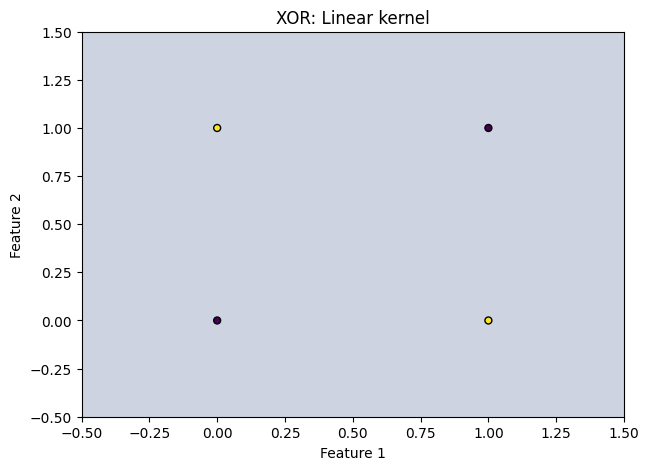

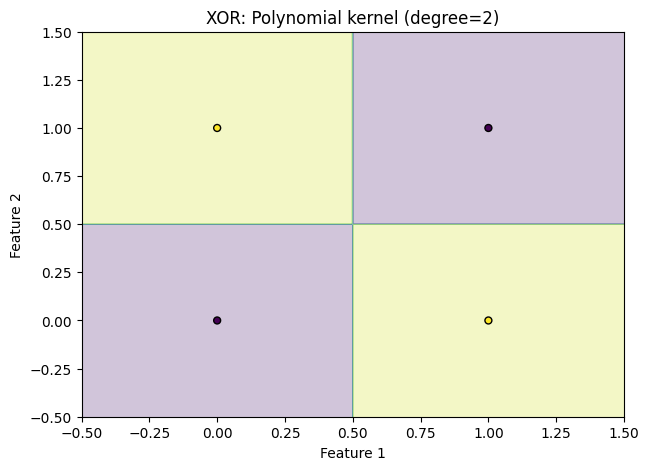

In [3]:
# Synthetic XOR dataset
X_xor = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1],
], dtype=float)
y_xor = np.array([0, 1, 1, 0])

lin = Pipeline([("scaler", StandardScaler()), ("svm", SVC(kernel="linear", C=1.0))])
poly = Pipeline([("scaler", StandardScaler()), ("svm", SVC(kernel="poly", degree=2, coef0=1.0, C=10.0, gamma="scale"))])

lin.fit(X_xor, y_xor)
poly.fit(X_xor, y_xor)

print("Linear XOR predictions:", lin.predict(X_xor))
print("Poly(2) XOR predictions:", poly.predict(X_xor))

plot_decision_boundary_2d(lin, X_xor, y_xor, title="XOR: Linear kernel")
plot_decision_boundary_2d(poly, X_xor, y_xor, title="XOR: Polynomial kernel (degree=2)")

---
### آزمایش ۱ — Iris (۲ ویژگی) + مرز تصمیم

Dataset: `../../../Datasets/Classification/iris.csv`


In [4]:
iris_path = "../../../Datasets/Classification/iris.csv"
df_iris = load_csv(iris_path)
df_iris.head()

,sepal_length,sepal_width,petal_length,petal_width,classification
0,5.4,3.7,1.5,0.2,Iris-setosa
1,4.8,3.4,1.6,0.2,Iris-setosa
2,4.8,3.0,1.4,0.1,Iris-setosa
3,4.3,3.0,1.1,0.1,Iris-setosa
4,5.8,4.0,1.2,0.2,Iris-setosa


In [5]:
X = df_iris[["petal_length", "petal_width"]].values
y_str = df_iris["classification"].astype(str).values

le = LabelEncoder()
y = le.fit_transform(y_str)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

lin_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="linear", C=1.0))
])

rbf_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=1.0, gamma="scale"))
])

lin_clf.fit(X_train, y_train)
rbf_clf.fit(X_train, y_train)

pred_lin = lin_clf.predict(X_test)
pred_rbf = rbf_clf.predict(X_test)

print("Linear SVM accuracy:", accuracy_score(y_test, pred_lin))
print("RBF SVM accuracy   :", accuracy_score(y_test, pred_rbf))
print("Classes:", list(le.classes_))

Linear SVM accuracy: 0.9210526315789473
RBF SVM accuracy   : 0.9210526315789473
Classes: ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']


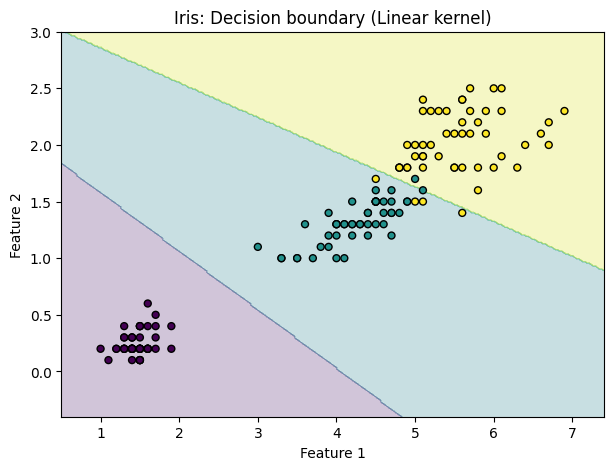

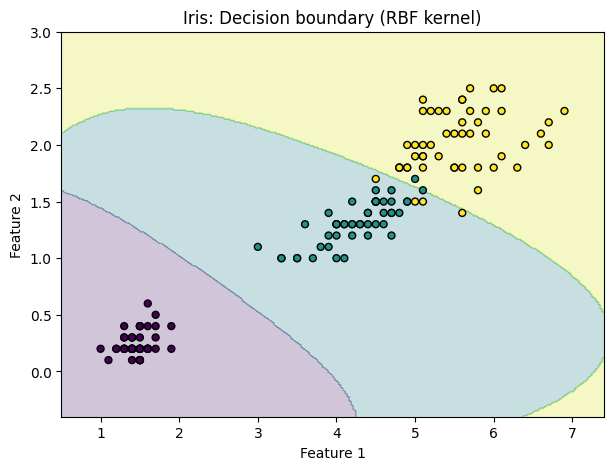

In [6]:
plot_decision_boundary_2d(lin_clf, X, y, title="Iris: Decision boundary (Linear kernel)")
plot_decision_boundary_2d(rbf_clf, X, y, title="Iris: Decision boundary (RBF kernel)")

---
### آزمایش ۱B — نمایش ماتریس گرام RBF (شباهت‌ها)


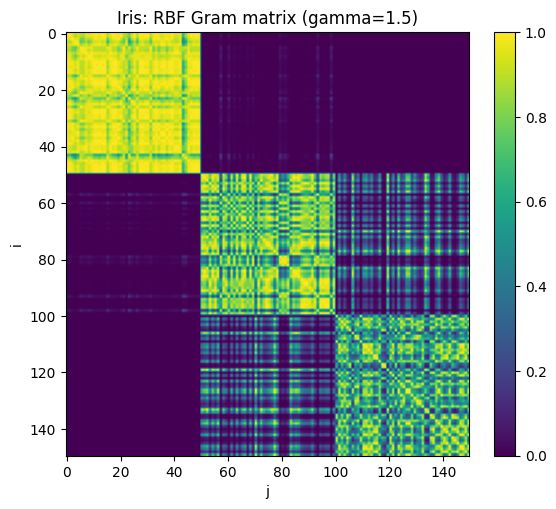

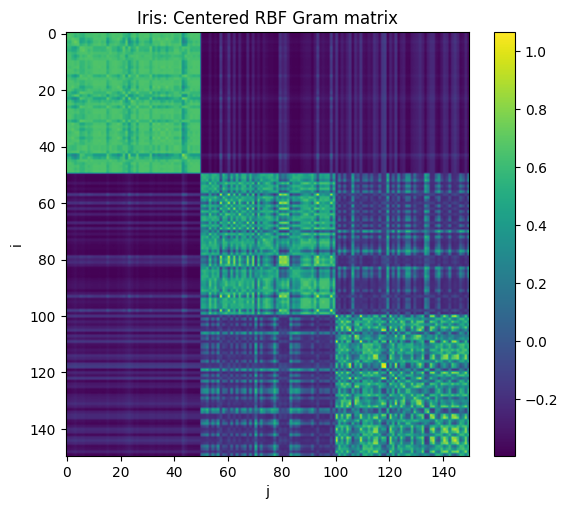

In [7]:
X_s = StandardScaler().fit_transform(X)
K = rbf_kernel_matrix(X_s, gamma=1.5)
heatmap(K, title="Iris: RBF Gram matrix (gamma=1.5)", xlabel="j", ylabel="i")

# Centered Gram matrix (used in kernel PCA)
Kc = center_gram_matrix(K)
heatmap(Kc, title="Iris: Centered RBF Gram matrix", xlabel="j", ylabel="i")

---
### آزمایش ۲ — poly kernel در برابر PolynomialFeatures


In [8]:
poly_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="poly", degree=3, coef0=1.0, C=2.0, gamma="scale"))
])

poly_explicit = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=3, include_bias=False)),
    ("clf", LogisticRegression(max_iter=5000))
])

poly_svm.fit(X_train, y_train)
poly_explicit.fit(X_train, y_train)

pred_poly_svm = poly_svm.predict(X_test)
pred_poly_explicit = poly_explicit.predict(X_test)

print("Poly-kernel SVM accuracy:", accuracy_score(y_test, pred_poly_svm))
print("Explicit poly + linear  :", accuracy_score(y_test, pred_poly_explicit))

Poly-kernel SVM accuracy: 0.9210526315789473
Explicit poly + linear  : 0.9473684210526315


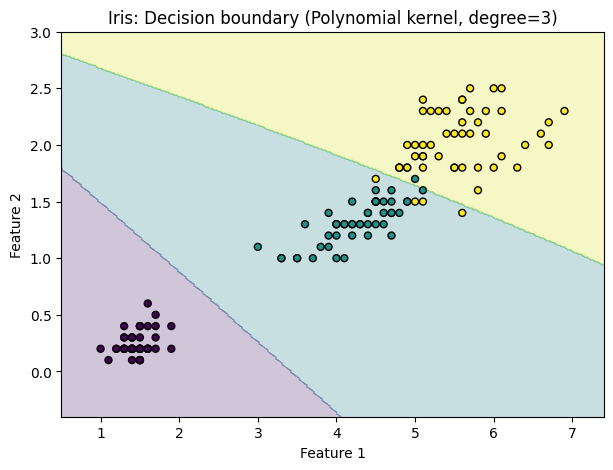

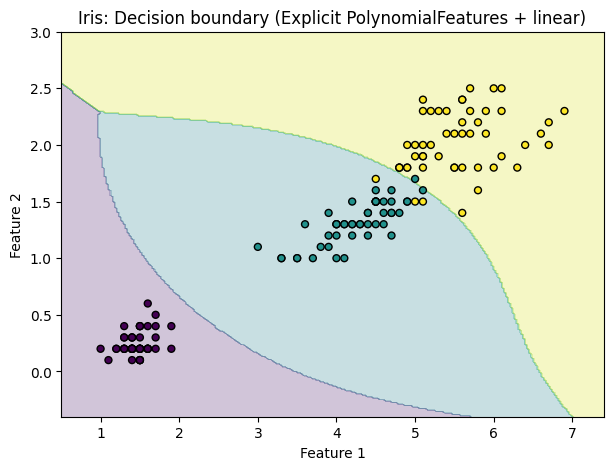

In [9]:
plot_decision_boundary_2d(poly_svm, X, y, title="Iris: Decision boundary (Polynomial kernel, degree=3)")
plot_decision_boundary_2d(poly_explicit, X, y, title="Iris: Decision boundary (Explicit PolynomialFeatures + linear)")

---
### آزمایش ۳ — بررسی PSD: RBF معتبر در برابر شباهت نامعتبر


RBF kernel matrix eigenvalues (min, max): -1.6520437096770676e-15 10.761929843125404
Weird similarity eigenvalues (min, max): -7.413034093007467 14.877241945425576


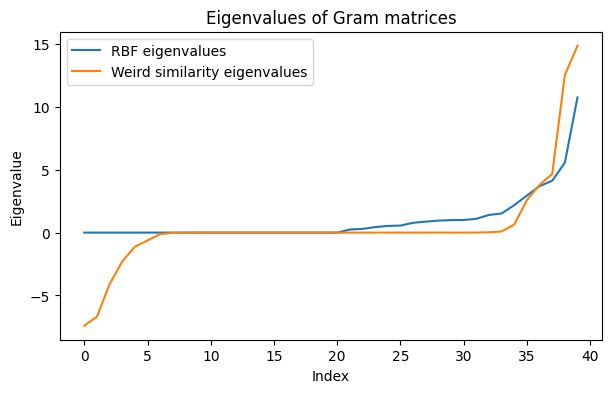

In [10]:
X_sub = X[:40]
X_sub_s = StandardScaler().fit_transform(X_sub)

def weird_similarity_matrix(X):
    # Not guaranteed PSD. This is just a counterexample-like similarity.
    return np.sin(X @ X.T)

K_rbf = rbf_kernel_matrix(X_sub_s, gamma=1.5)
K_weird = weird_similarity_matrix(X_sub_s)

eig_rbf = np.linalg.eigvalsh((K_rbf + K_rbf.T)/2)
eig_weird = np.linalg.eigvalsh((K_weird + K_weird.T)/2)

print("RBF kernel matrix eigenvalues (min, max):", float(eig_rbf.min()), float(eig_rbf.max()))
print("Weird similarity eigenvalues (min, max):", float(eig_weird.min()), float(eig_weird.max()))

plt.figure(figsize=(7,4))
plt.plot(eig_rbf, label="RBF eigenvalues")
plt.plot(eig_weird, label="Weird similarity eigenvalues")
plt.title("Eigenvalues of Gram matrices")
plt.xlabel("Index")
plt.ylabel("Eigenvalue")
plt.legend()
plt.show()

---
### آزمایش ۳B — استفاده از کرنل پیش‌محاسبه‌شده (precomputed)


In [11]:
# Build RBF kernel matrices manually on Iris
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

gamma = 1.5
K_train = rbf_kernel_matrix(X_train_s, gamma=gamma)
K_test  = np.exp(-gamma * np.sum((X_test_s[:, None, :] - X_train_s[None, :, :])**2, axis=2))

svc_pre = SVC(kernel="precomputed", C=1.0)
svc_pre.fit(K_train, y_train)
pred_pre = svc_pre.predict(K_test)

print("Precomputed-kernel SVC accuracy:", accuracy_score(y_test, pred_pre))
print("Support vectors:", svc_pre.n_support_)

Precomputed-kernel SVC accuracy: 0.9473684210526315
Support vectors: [ 3  9 11]


---
### آزمایش ۴ — Fish چندکلاسه + مقایسهٔ کرنل‌ها

Dataset: `../../../Datasets/Classification/fish.csv`


In [12]:
fish_path = "../../../Datasets/Classification/fish.csv"
df_fish = load_csv(fish_path)
df_fish.head()

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


In [13]:
Xf = df_fish.drop(columns=["Species"]).values
yf_str = df_fish["Species"].astype(str).values
yf = LabelEncoder().fit_transform(yf_str)

Xf_train, Xf_test, yf_train, yf_test = train_test_split(
    Xf, yf, test_size=0.25, random_state=42, stratify=yf
)

models = {
    "linear": Pipeline([("scaler", StandardScaler()), ("svm", SVC(kernel="linear", C=1.0))]),
    "rbf":    Pipeline([("scaler", StandardScaler()), ("svm", SVC(kernel="rbf", C=5.0, gamma="scale"))]),
    "poly":   Pipeline([("scaler", StandardScaler()), ("svm", SVC(kernel="poly", degree=3, coef0=1.0, C=2.0, gamma="scale"))]),
}

for name, clf in models.items():
    clf.fit(Xf_train, yf_train)
    pred = clf.predict(Xf_test)
    print(f"{name:6s} accuracy:", accuracy_score(yf_test, pred))

linear accuracy: 0.825
rbf    accuracy: 0.825
poly   accuracy: 0.85


---
### آزمایش ۵ — Glass چندکلاسه + PCA + تعداد بردارهای پشتیبان

Dataset: `../../../Datasets/Classification/glass.csv`


In [14]:
glass_path = "../../../Datasets/Classification/glass.csv"
df_glass = load_csv(glass_path)
df_glass.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,building_windows_float_processed
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,building_windows_float_processed
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,building_windows_float_processed
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,building_windows_float_processed
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,building_windows_float_processed


In [15]:
Xg = df_glass.drop(columns=["Type"]).values
yg_str = df_glass["Type"].astype(str).values
yg = LabelEncoder().fit_transform(yg_str)

Xg_train, Xg_test, yg_train, yg_test = train_test_split(
    Xg, yg, test_size=0.25, random_state=42, stratify=yg
)

rbf_glass = Pipeline([("scaler", StandardScaler()), ("svm", SVC(kernel="rbf", C=5.0, gamma="scale"))])
rbf_glass.fit(Xg_train, yg_train)

pred = rbf_glass.predict(Xg_test)
print("RBF SVM accuracy:", accuracy_score(yg_test, pred))

# Number of support vectors per class
svm = rbf_glass.named_steps["svm"]
print("Support vectors per class:", svm.n_support_)

RBF SVM accuracy: 0.7592592592592593
Support vectors per class: [40 44  9 11  6 13]


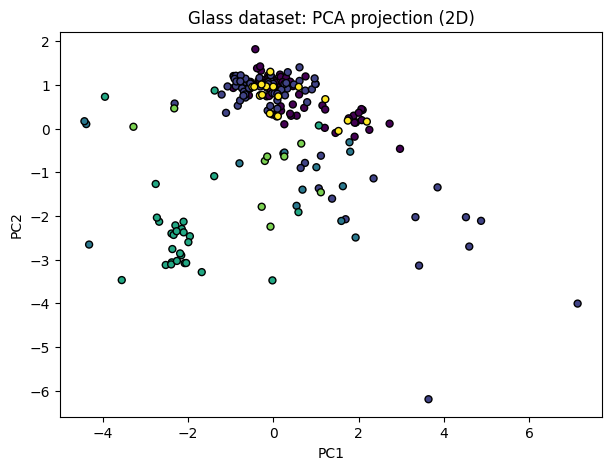

In [16]:
# PCA visualization (for intuition only)
Xg_scaled = StandardScaler().fit_transform(Xg)
Xg_2d = PCA(n_components=2, random_state=42).fit_transform(Xg_scaled)

plt.figure(figsize=(7,5))
plt.scatter(Xg_2d[:,0], Xg_2d[:,1], c=yg, s=25, edgecolor="k")
plt.title("Glass dataset: PCA projection (2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

---
### آزمایش ۶ — Diabetes دودویی + GridSearch + تعداد بردارهای پشتیبان

Dataset: `../../../Datasets/Classification/diabetes.csv`


In [17]:
diabetes_path = "../../../Datasets/Classification/diabetes.csv"
df_diab = load_csv(diabetes_path)
df_diab.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,classification
0,6,148,72,35,0,33.6,0.627,50,Diabetic
1,1,85,66,29,0,26.6,0.351,31,Non-Diabetic
2,8,183,64,0,0,23.3,0.672,32,Diabetic
3,1,89,66,23,94,28.1,0.167,21,Non-Diabetic
4,0,137,40,35,168,43.1,2.288,33,Diabetic


In [18]:
Xd = df_diab.drop(columns=["classification"]).values
yd_str = df_diab["classification"].astype(str).values
yd = LabelEncoder().fit_transform(yd_str)

Xd_train, Xd_test, yd_train, yd_test = train_test_split(
    Xd, yd, test_size=0.25, random_state=42, stratify=yd
)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf"))
])

param_grid = {
    "svm__C": [0.5, 1, 2, 5, 10],
    "svm__gamma": ["scale", 0.01, 0.05, 0.1, 0.2]
}

gs = GridSearchCV(pipe, param_grid=param_grid, cv=5, n_jobs=-1)
gs.fit(Xd_train, yd_train)

print("Best params:", gs.best_params_)
best = gs.best_estimator_
pred = best.predict(Xd_test)

print("Test accuracy:", accuracy_score(yd_test, pred))
print(classification_report(yd_test, pred))

svm = best.named_steps["svm"]
print("Support vectors:", svm.support_.shape[0])

Best params: {'svm__C': 1, 'svm__gamma': 0.01}
Test accuracy: 0.7760416666666666
              precision    recall  f1-score   support

           0       0.75      0.54      0.63        67
           1       0.78      0.90      0.84       125

    accuracy                           0.78       192
   macro avg       0.77      0.72      0.73       192
weighted avg       0.77      0.78      0.77       192

Support vectors: 346


---
### آزمایش ۶B — تقریب RBF با Random Fourier Features


In [19]:
# Kernel SVM baseline (already computed as best)
baseline_acc = accuracy_score(yd_test, pred)

# RFF + LinearSVC
rff_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("rff", RBFSampler(gamma=0.05, n_components=2000, random_state=42)),
    ("lin", LinearSVC(C=1.0, max_iter=5000))
])

rff_pipe.fit(Xd_train, yd_train)
pred_rff = rff_pipe.predict(Xd_test)

print("Baseline kernel SVM accuracy:", baseline_acc)
print("RFF + LinearSVC accuracy    :", accuracy_score(yd_test, pred_rff))

Baseline kernel SVM accuracy: 0.7760416666666666
RFF + LinearSVC accuracy    : 0.7916666666666666


---
### آزمایش ۶C — تقریب Nyström


In [20]:
nys_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("nys", Nystroem(kernel="rbf", gamma=0.05, n_components=800, random_state=42)),
    ("lin", LinearSVC(C=1.0, max_iter=5000))
])

nys_pipe.fit(Xd_train, yd_train)
pred_nys = nys_pipe.predict(Xd_test)

print("Nyström + LinearSVC accuracy:", accuracy_score(yd_test, pred_nys))

C:\Users\LENOVO.PIESC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\kernel_approximation.py:1008: UserWarning: n_components > n_samples. This is not possible.
n_components was set to n_samples, which results in inefficient evaluation of the full kernel.
  warnings.warn(


Nyström + LinearSVC accuracy: 0.7864583333333334


---
### آزمایش ۷ — Kernel ridge regression (Wine Quality)

Dataset: `../../../Datasets/Classification/Wine_Quality.csv`


In [21]:
wine_path = "../../../Datasets/Classification/Wine_Quality.csv"
df_wine = load_csv(wine_path)
df_wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


KernelRidge (RBF) MAE   : 0.5635683525911918
KernelRidge (Linear) MAE: 5.890580097070423


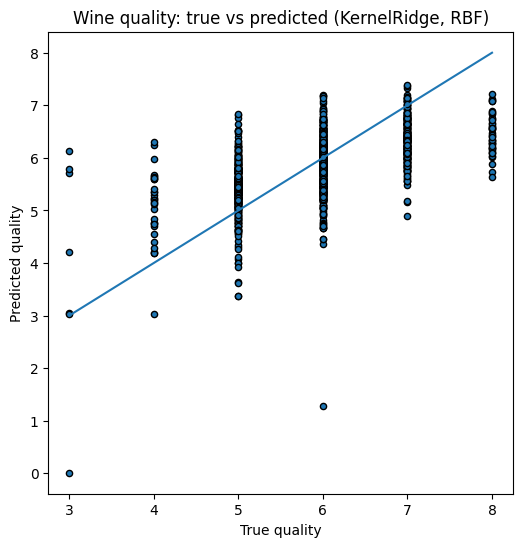

In [22]:
Xw = df_wine.drop(columns=["quality"]).values
yw = df_wine["quality"].values.astype(float)

Xw_train, Xw_test, yw_train, yw_test = train_test_split(
    Xw, yw, test_size=0.25, random_state=42
)

kr_rbf = Pipeline([
    ("scaler", StandardScaler()),
    ("kr", KernelRidge(kernel="rbf", gamma=0.05, alpha=1.0))
])

kr_lin = Pipeline([
    ("scaler", StandardScaler()),
    ("kr", KernelRidge(kernel="linear", alpha=1.0))
])

kr_rbf.fit(Xw_train, yw_train)
kr_lin.fit(Xw_train, yw_train)

pred_rbf = kr_rbf.predict(Xw_test)
pred_lin = kr_lin.predict(Xw_test)

print("KernelRidge (RBF) MAE   :", mean_absolute_error(yw_test, pred_rbf))
print("KernelRidge (Linear) MAE:", mean_absolute_error(yw_test, pred_lin))

plt.figure(figsize=(6,6))
plt.scatter(yw_test, pred_rbf, s=20, edgecolor="k")
plt.title("Wine quality: true vs predicted (KernelRidge, RBF)")
plt.xlabel("True quality")
plt.ylabel("Predicted quality")
plt.plot([yw_test.min(), yw_test.max()], [yw_test.min(), yw_test.max()])
plt.show()

---
### آزمایش ۸ — SVR با ویژگی‌های ترکیبی (House Prices)

Dataset: `../../../Datasets/Regression/house-prices.csv`


In [23]:
hp_path = "../../../Datasets/Regression/house-prices.csv"
df_hp = load_csv(hp_path)
df_hp.head()

,Home,Price,SqFt,Bedrooms,Bathrooms,Offers,Brick,Neighborhood
0,1,114300,1790,2,2,2,No,East
1,2,114200,2030,4,2,3,No,East
2,3,114800,1740,3,2,1,No,East
3,4,94700,1980,3,2,3,No,East
4,5,119800,2130,3,3,3,No,East


SVR MAE: 20265.100746781114


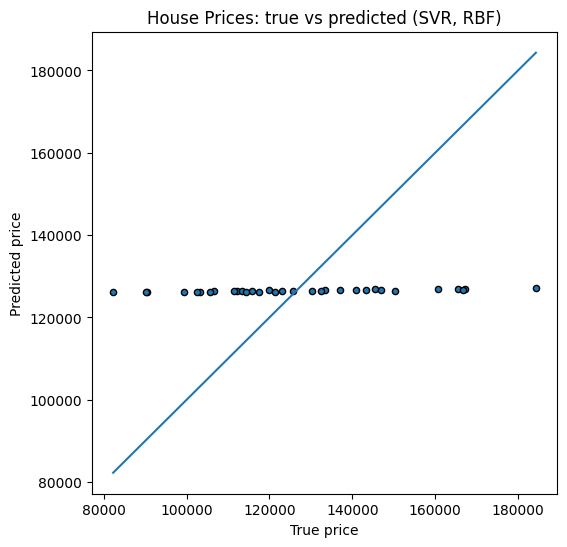

In [24]:
target = "Price"
Xhp = df_hp.drop(columns=[target])
yhp = df_hp[target].astype(float).values

num_cols = Xhp.select_dtypes(include=["number"]).columns.tolist()
cat_cols = [c for c in Xhp.columns if c not in num_cols]

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer([
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols),
])

svr = SVR(kernel="rbf", C=50.0, gamma="scale", epsilon=0.1)

svr_pipe = Pipeline([
    ("prep", preprocess),
    ("svr", svr),
])

Xhp_train, Xhp_test, yhp_train, yhp_test = train_test_split(
    Xhp, yhp, test_size=0.25, random_state=42
)

svr_pipe.fit(Xhp_train, yhp_train)
pred_hp = svr_pipe.predict(Xhp_test)

print("SVR MAE:", mean_absolute_error(yhp_test, pred_hp))

plt.figure(figsize=(6,6))
plt.scatter(yhp_test, pred_hp, s=20, edgecolor="k")
plt.title("House Prices: true vs predicted (SVR, RBF)")
plt.xlabel("True price")
plt.ylabel("Predicted price")
plt.plot([yhp_test.min(), yhp_test.max()], [yhp_test.min(), yhp_test.max()])
plt.show()

---
### آزمایش ۹ — Kernel PCA (bonus)


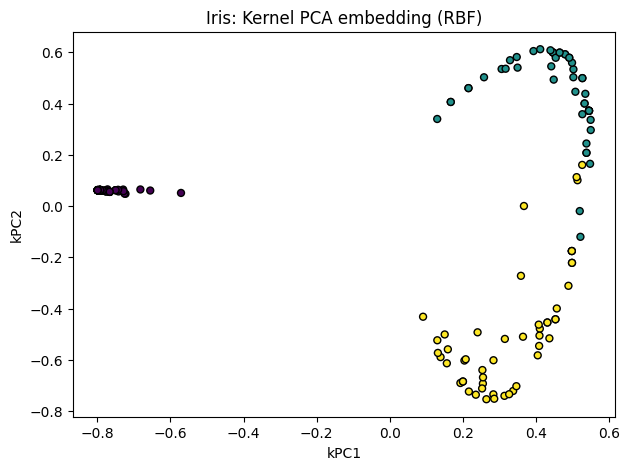

Top eigenvalues: [46.4045283  26.27481287 12.21461239  5.51082243  4.4724524   2.52194387
  2.11869078  1.43441101  1.05144118  0.97262426]


In [25]:
# Kernel PCA (manual) on Iris
Xk = StandardScaler().fit_transform(X)
K = rbf_kernel_matrix(Xk, gamma=1.5)
Kc = center_gram_matrix(K)

eigvals, eigvecs = np.linalg.eigh((Kc + Kc.T)/2)
# sort descending
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

# coordinates (scaled by sqrt eigenvalues)
Z = eigvecs[:, :2] * np.sqrt(np.maximum(eigvals[:2], 0))

plt.figure(figsize=(7,5))
plt.scatter(Z[:,0], Z[:,1], c=y, s=25, edgecolor="k")
plt.title("Iris: Kernel PCA embedding (RBF)")
plt.xlabel("kPC1")
plt.ylabel("kPC2")
plt.show()

print("Top eigenvalues:", eigvals[:10])

---
## تمرین‌ها

1) با رابطهٔ $\|\phi(x_i)-\phi(x_j)\|^2 = k(x_i,x_i)+k(x_j,x_j)-2k(x_i,x_j)$ یک ماتریس فاصلهٔ فضای ویژگی بسازید و رسم کنید.
2) روی `diabetes.csv` یک نقشهٔ حساسیت برای $(C,\gamma)$ بسازید و توضیح دهید چرا $\gamma$ بسیار بزرگ معمولاً بیش‌برازش می‌دهد.
3) نشان دهید `SVC(kernel="rbf")` و `SVC(kernel="precomputed")` وقتی کرنل یکسان است نتایج مشابه می‌دهند.
4) یک کرنل ترکیبی بسازید (مثلاً ۰٫۵ RBF + ۰٫۵ poly) و روی یک دیتاست تست کنید.
5) در RFF و Nyström مقدار `n_components` را تغییر دهید و روند دقت را تحلیل کنید.


---
## جمع‌بندی

- کرنل‌ها ضرب داخلی در فضای ویژگی‌اند: $k(x,z)=\langle\phi(x),\phi(z)\rangle$.
- poly متناظر با بسط محدودبُعد و RBF متناظر با بسط بی‌نهایت‌بُعد است.
- کرنل معتبر باید ماتریس گرام PSD تولید کند؛ PSD برای تحدب/مقعربودن دوگان SVM لازم است.
- در عمل: scaling، تنظیم $(C,\gamma)$، و استفاده از تقریب‌ها در $n$ بزرگ کلیدی است.
